# 04 Korrelasjon
*Data Mining & Analytics – Samling 2, dag 1*


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.5)
rng = np.random.default_rng(42) 

## Pearson r



r ∈ [−1, 1] og måler lineær samvariasjon.

Manuell:   0.873
numpy:      0.873
scipy:      r = 0.873,  p = 3.13e-105,  95 % KI = [0.845 0.896]
R² = 0.762  -> andel av variansen i kroppsvekt 'forklart' lineært av vingelengde


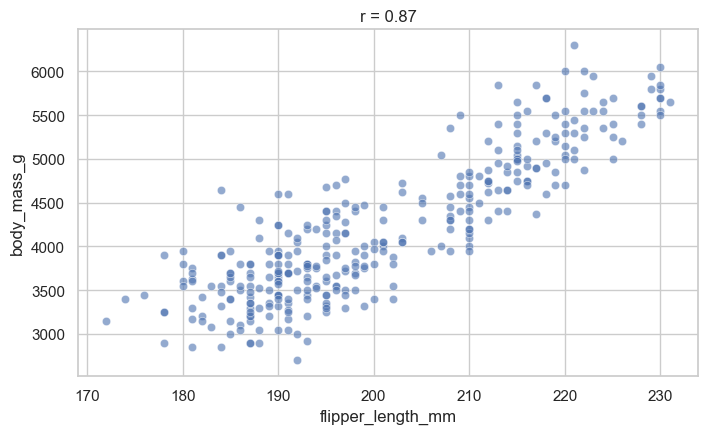

In [2]:
pingvin = pd.read_csv("../Data/penguins.csv").dropna()
x, y = pingvin["flipper_length_mm"], pingvin["body_mass_g"]


r_manuell = ((x - x.mean()) * (y - y.mean())).sum() / np.sqrt(((x - x.mean())**2).sum() * ((y - y.mean())**2).sum())
print("Manuell:  ", r_manuell.round(4))
print("numpy:     ", np.corrcoef(x, y)[0, 1].round(4))
res = stats.pearsonr(x, y)
print(f"scipy:      r = {res.statistic:.3f},  p = {res.pvalue:.2e},  95 % KI = {np.round(res.confidence_interval(), 3)}")
print("R² =", (res.statistic**2).round(3), " -> andel av variansen i kroppsvekt 'forklart' lineært av vingelengde")

sns.scatterplot(x=x, y=y, alpha=0.6)
plt.title(f"r = {res.statistic:.2f}")
plt.show()

Hvordan ser ulike r-verdier ut?

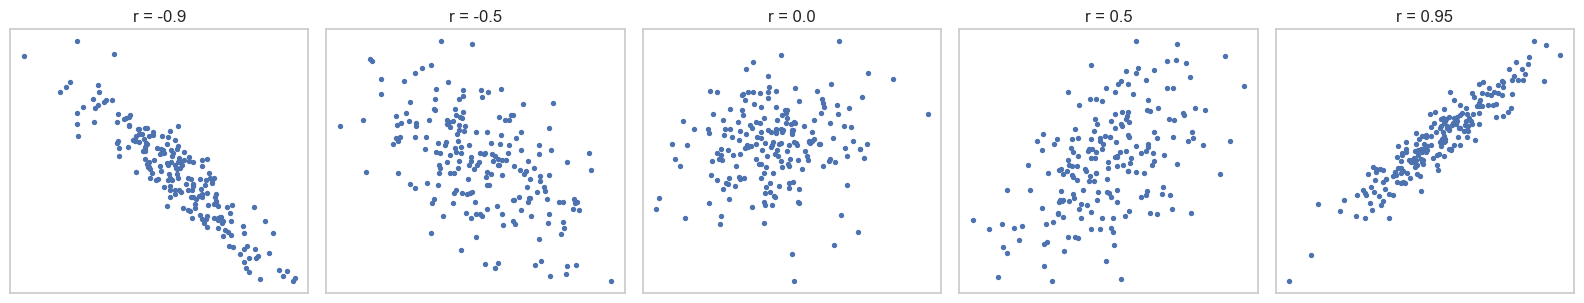

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3.2))
for ax, r in zip(axes, [-0.9, -0.5, 0.0, 0.5, 0.95]):
    d = rng.multivariate_normal([0, 0], [[1, r], [r, 1]], 200)
    ax.scatter(d[:, 0], d[:, 1], s=8)
    ax.set_title(f"r = {r}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## Anscombes kvartett

Fire datasett med nesten identisk gjennomsnitt, varians, r og regresjonslinje, men helt ulik struktur.

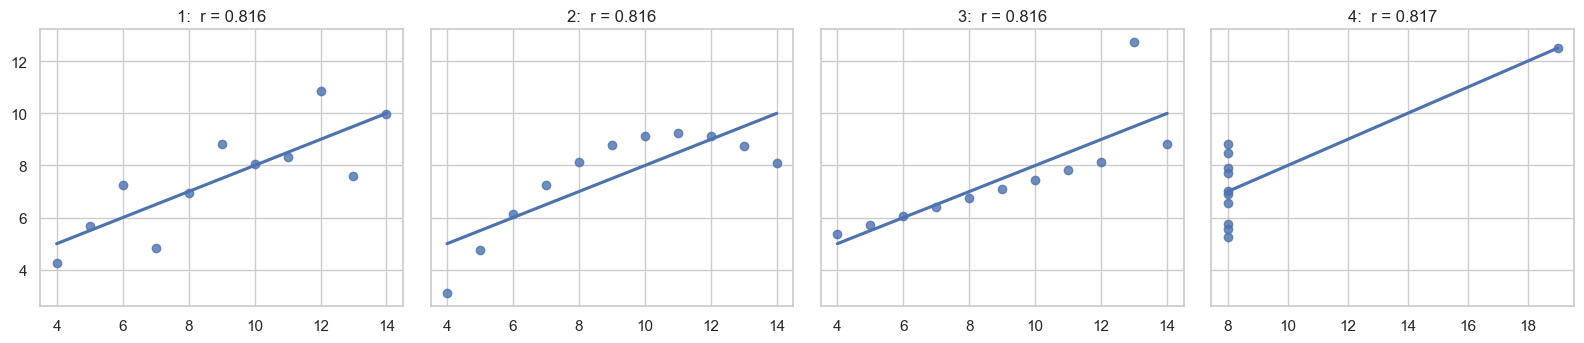

In [4]:
x = [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5]
anscombe = {
    "1":   (x, [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]),
    "2":  (x, [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]),
    "3": (x, [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]),
    "4":  ([8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8], [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89]),
}
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharey=True)
for ax, (navn, (xa, ya)) in zip(axes, anscombe.items()):
    r = np.corrcoef(xa, ya)[0, 1]
    sns.regplot(x=np.array(xa), y=np.array(ya), ax=ax, ci=None)
    ax.set_title(f"{navn}:  r = {r:.3f}")
plt.tight_layout()
plt.show()

## Korrelasjon ≠ kausalitet

### Konfunderende variabel
Isvolum solgt og drukningsulykker korrelerer, men sannsyligvis er det ingen årask virkning mellom de to. Det er større sannsynlighet for at de begge drives av temperatur.

In [5]:
temp = rng.normal(15, 8, 300)
iskrem = 20 + 3.0 * temp + rng.normal(0, 10, 300)
drukning = 1 + 0.15 * temp + rng.normal(0, 1.0, 300)
df = pd.DataFrame({"temp": temp, "iskrem": iskrem, "drukning": drukning})

print("r(iskrem, drukning) =", df["iskrem"].corr(df["drukning"]).round(2))

# partiell korrelasjon: fjern effekten av temp fra både iskrem og drukning
def resid(a, b):
    koef = np.polyfit(b, a, 1)
    return a - np.polyval(koef, b)

print("Partiell korrelasjon (kontrollert/korrigert for temp) =", np.corrcoef(resid(df["iskrem"], df["temp"]), resid(df["drukning"], df["temp"]))[0, 1].round(2))

r(iskrem, drukning) = 0.69
Partiell korrelasjon (kontrollert/korrigert for temp) = 0.03


## Korrelasjonsmatriser og kategoriske sammenhenger

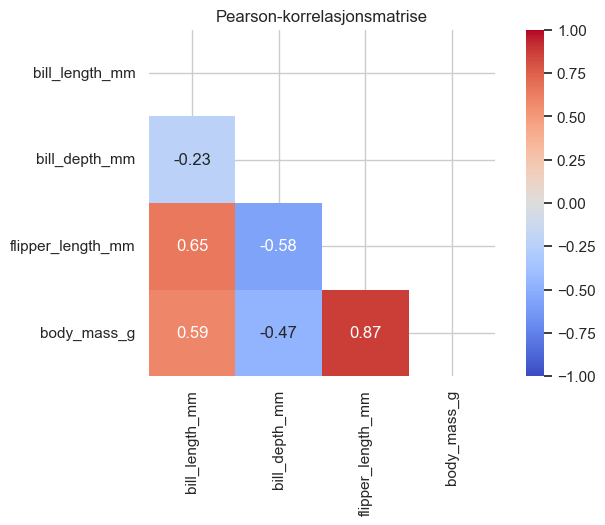

In [6]:
num = pingvin.select_dtypes("number")
korr = num.corr()
mask = np.triu(np.ones_like(korr, dtype=bool))
sns.heatmap(korr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, mask=mask, square=True)
plt.title("Pearson-korrelasjonsmatrise")
plt.show()